In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import scipy.stats as stats

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

# 실행결과 경고메시지 출력 제외
import warnings
warnings.filterwarnings('ignore')

# 영향인자 유의성 검정

## 데이터 불러오기

In [46]:
df = pd.read_csv("../B1_data/preprocessing_data/final_data.csv")
df.head()

,type,Temp_OXid,ppm,Pressure,Oxid_time,N2_HMDS,pressure_HMDS,temp_HMDS,time_HMDS_bake,spin1,...,Energy_Exposure,Source_Power,Temp_Etching,etching_velo,max_flux,input_Energy,Temp_implantation,Furance_Temp,RTA_Temp,y_label
0,dry,1214.33,26.78,0.30,120,17.362,15.112,19.893,89.963,502.276,...,109.653,52.080,72.628,2.995556,6.470000e+17,30795.856,103.513,854.0,154,0
1,dry,977.98,30.90,0.14,137,16.015,15.083,20.035,89.988,507.132,...,104.946,52.028,70.220,3.035556,1.040000e+18,32135.659,105.628,895.0,156,0
2,dry,1175.95,31.11,0.25,116,19.229,14.917,19.884,89.918,501.579,...,106.563,50.705,71.140,2.954444,6.470000e+17,31057.876,102.716,898.0,152,0
3,dry,933.47,31.20,0.29,143,18.894,14.886,20.023,90.094,503.475,...,108.696,51.550,71.306,2.994444,3.410000e+17,32140.435,102.902,879.0,155,0
4,wet,1140.60,31.38,0.20,76,13.851,14.705,20.000,90.070,501.384,...,109.944,50.681,72.982,3.061111,7.260000e+17,31985.989,101.465,882.0,155,0


In [47]:
df.drop(['kperna','etching_velo'], axis =1, inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14816 entries, 0 to 14815
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   type               14816 non-null  object 
 1   Temp_OXid          14816 non-null  float64
 2   ppm                14816 non-null  float64
 3   Pressure           14816 non-null  float64
 4   Oxid_time          14816 non-null  int64  
 5   N2_HMDS            14816 non-null  float64
 6   pressure_HMDS      14816 non-null  float64
 7   temp_HMDS          14816 non-null  float64
 8   time_HMDS_bake     14816 non-null  float64
 9   spin1              14816 non-null  float64
 10  spin2              14816 non-null  float64
 11  spin3              14816 non-null  float64
 12  photoresist_bake   14816 non-null  float64
 13  temp_softbake      14816 non-null  float64
 14  time_softbake      14816 non-null  float64
 15  Energy_Exposure    14816 non-null  float64
 16  Source_Power       148

In [48]:
df['y_label'].value_counts()

0    13741
1     1075
Name: y_label, dtype: int64

## 2 sample t-test

In [51]:
def twosamplt_ttest(test_df, column_name, mode = 0):

    neg_df = test_df[test_df['y_label'] == 0][column_name]
    pos_df = test_df[test_df['y_label'] == 1][column_name]
    stat,p = stats.bartlett(neg_df, pos_df)
    print( "1. 등분산성 검정 ")
    print( "  검정통계량: {:.4f} " .format(stat), end="") ; print( " p-value : {:.4f} " .format(p))
    if p > 0.05:
        equal_var = True
        print( "2. 2-Sample t-test ")
    else:
        equal_var = False
        print( "2. Welch’s t-test ")
        
    t_result = stats.ttest_ind(neg_df, pos_df, equal_var = equal_var)
    t, p = t_result.statistic, t_result.pvalue

    print( "  t검정통계량: {:.4f} " .format(t), end="") ; print( " p-value : {:.4f} " .format(p))
    if p < 0.05:
        print("H1: 채택,",column_name,"에 따른 불량품/양품의 차이가 있다")
    else:
        print("H0: 채택,",column_name,"에 따른 불량품/양품의 차이가 없다")
    
    if mode == 1:
        graph_df = pd.DataFrame({
        column_name: np.concatenate([neg_df, pos_df]),
        "Category": ["양품"] * len(neg_df) + ["불량품"] * len(pos_df)
        })
        #fig, axes = plt.subplots(1, 1, figsize=(5, 5))  
        
        sns.boxplot(x="Category", y=column_name, data=graph_df, palette=["lightblue", "lightcoral"])
        #plt.savefig("./유의성검/"+ column_name +" Boxplot.png")
        plt.title(column_name +" Boxplot")
        # sns.kdeplot(neg_df, fill=True, color="lightblue", label="양품", ax=axes[1])
        # sns.kdeplot(pos_df, fill=True, color="lightcoral", label="불량품", ax=axes[1])

        # axes[1].set_title(column_name + " KDE Plot")
        # axes[1].legend()
        
        # axes[2].hist(neg_df, bins=20, alpha=0.6, color="blue", label="양품")
        # axes[2].hist(pos_df, bins=20, alpha=0.6, color="red", label="불량품")
        # axes[2].set_title(column_name +" Histogram")
        # axes[2].legend()
        
        # plt.tight_layout()
        plt.show()

In [52]:
def show_describe(test_df, column_name):
    neg_df = test_df[test_df['y_label'] == 0][column_name]
    pos_df = test_df[test_df['y_label'] == 1][column_name]
    
    nd = neg_df.describe().values
    po = pos_df.describe().values
    temp = pd.DataFrame({ 
        '양품' : nd,
        '불량품' : po,
        '전체' : test_df[column_name].describe().values}, index = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'])
    display(temp)

##### 1. 산화공정
* Temp_OXid
* ppm
* Pressure
* Oxid_time

1. 등분산성 검정 
  검정통계량: 0.4498  p-value : 0.5024 
2. 2-Sample t-test 
  t검정통계량: 14.6061  p-value : 0.0000 
H1: 채택, Temp_OXid 에 따른 불량품/양품의 차이가 있다


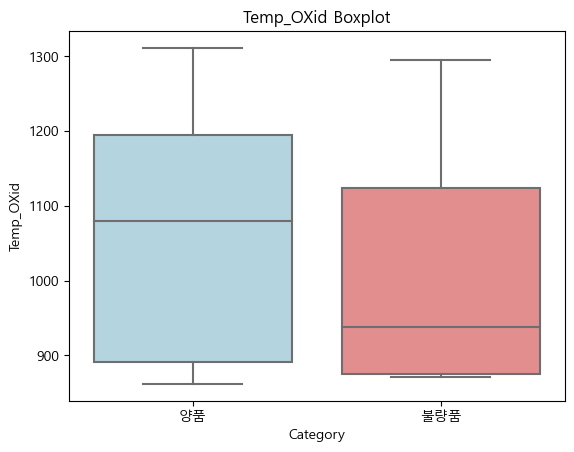

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,1073.354849,1004.434112,1068.354188
std,148.828435,151.072173,150.056167
min,861.790000,870.750000,861.790000
25%,890.700000,875.245000,888.540000
50%,1079.360000,937.500000,1073.435000
75%,1194.650000,1123.530000,1191.062500
max,1311.320000,1294.700000,1311.320000


In [38]:
# 1. Temp_Oxid
twosamplt_ttest(df, 'Temp_OXid', 1)
show_describe(df, 'Temp_OXid')

1. 등분산성 검정 
  검정통계량: 0.5577  p-value : 0.4552 
2. 2-Sample t-test 
  t검정통계량: 10.5710  p-value : 0.0000 
H1: 채택, ppm 에 따른 불량품/양품의 차이가 있다


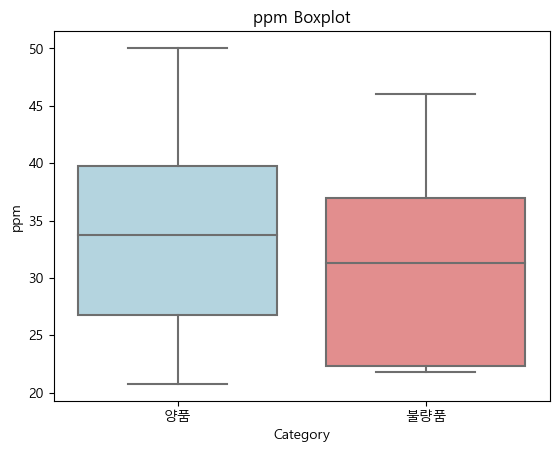

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,33.584096,30.880372,33.387923
std,8.066035,8.201492,8.106060
min,20.750000,21.800000,20.750000
25%,26.780000,22.350000,25.600000
50%,33.750000,31.270000,33.600000
75%,39.770000,36.950000,39.580000
max,50.050000,46.070000,50.050000


In [39]:
# 2. ppm
twosamplt_ttest(df, 'ppm', 1)
show_describe(df, 'ppm')

1. 등분산성 검정 
  검정통계량: 0.0713  p-value : 0.7895 
2. 2-Sample t-test 
  t검정통계량: -0.9369  p-value : 0.3488 
H0: 채택, Pressure 에 따른 불량품/양품의 차이가 없다


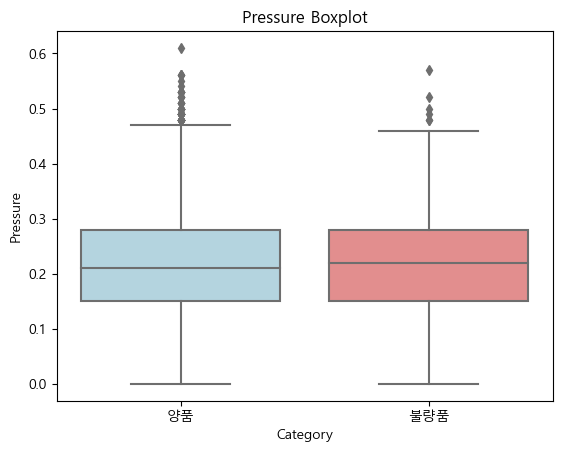

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,0.214755,0.217572,0.214960
std,0.094892,0.095460,0.094933
min,-0.000000,0.000000,-0.000000
25%,0.150000,0.150000,0.150000
50%,0.210000,0.220000,0.210000
75%,0.280000,0.280000,0.280000
max,0.610000,0.570000,0.610000


In [53]:
# 3. Pressure
twosamplt_ttest(df, 'Pressure', 1)
show_describe(df, 'Pressure')

1. 등분산성 검정 
  검정통계량: 33.8433  p-value : 0.0000 
2. Welch’s t-test 
  t검정통계량: -4.7212  p-value : 0.0000 
H1: 채택, Oxid_time 에 따른 불량품/양품의 차이가 있다


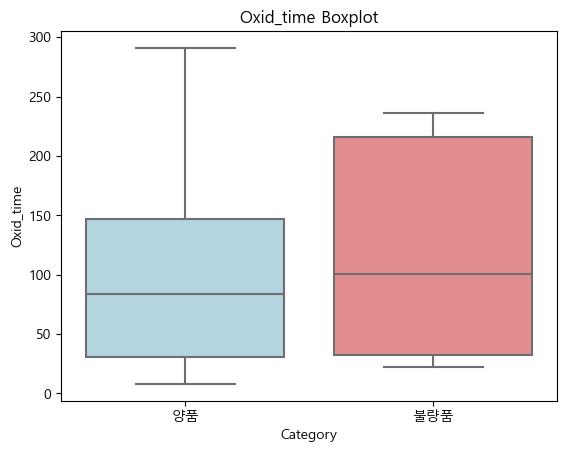

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,98.018849,110.046512,98.891536
std,71.635448,81.090299,72.427259
min,8.000000,22.000000,8.000000
25%,31.000000,32.000000,31.000000
50%,84.000000,101.000000,86.000000
75%,147.000000,216.000000,148.000000
max,291.000000,236.000000,291.000000


In [54]:
# 4. Oxid_time
twosamplt_ttest(df, 'Oxid_time', 1)
show_describe(df, 'Oxid_time')

##### 2. photo_soft
1. N2_HMDS
2. pressure_HMDS
3. time_HMDS
4. temp_HMDS_bake
5. spin1
6. spin2
7. spin3
8. photoresist_bake
9. temp_softbake
10. time_softbake

1. 등분산성 검정 
  검정통계량: 41.0000  p-value : 0.0000 
2. Welch’s t-test 
  t검정통계량: -0.7842  p-value : 0.4330 
H0: 채택, N2_HMDS 에 따른 불량품/양품의 차이가 없다


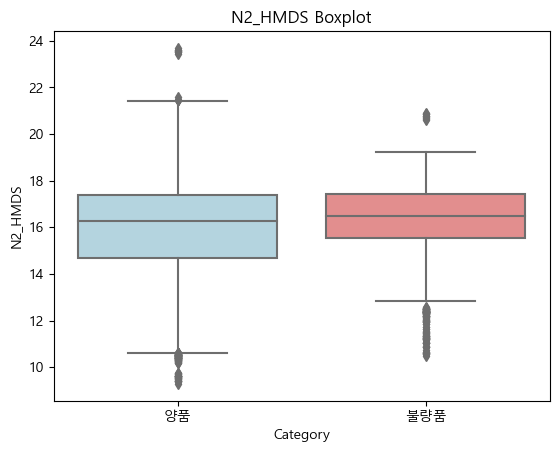

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,16.065792,16.114838,16.069351
std,2.265012,1.950172,2.243632
min,9.281000,10.497000,9.281000
25%,14.671000,15.539500,14.708500
50%,16.266000,16.478000,16.294000
75%,17.372000,17.422500,17.378000
max,23.690000,20.891000,23.690000


In [55]:
# 1. N2_HMDS
twosamplt_ttest(df, 'N2_HMDS', 1)
show_describe(df, 'N2_HMDS')

1. 등분산성 검정 
  검정통계량: 7.5942  p-value : 0.0059 
2. Welch’s t-test 
  t검정통계량: -0.4784  p-value : 0.6325 
H0: 채택, pressure_HMDS 에 따른 불량품/양품의 차이가 없다


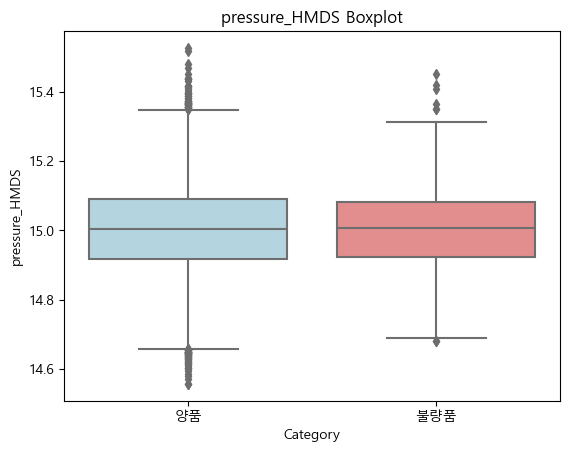

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,15.003413,15.005235,15.003545
std,0.127469,0.119703,0.126919
min,14.557000,14.681000,14.557000
25%,14.917000,14.924000,14.917000
50%,15.003000,15.008000,15.003500
75%,15.090000,15.082000,15.089000
max,15.526000,15.450000,15.526000


In [56]:
# 2. pressure_HMDS
twosamplt_ttest(df, 'pressure_HMDS', 1)
show_describe(df, 'pressure_HMDS')

1. 등분산성 검정 
  검정통계량: 0.1232  p-value : 0.7256 
2. 2-Sample t-test 
  t검정통계량: 0.5070  p-value : 0.6121 
H0: 채택, temp_HMDS 에 따른 불량품/양품의 차이가 없다


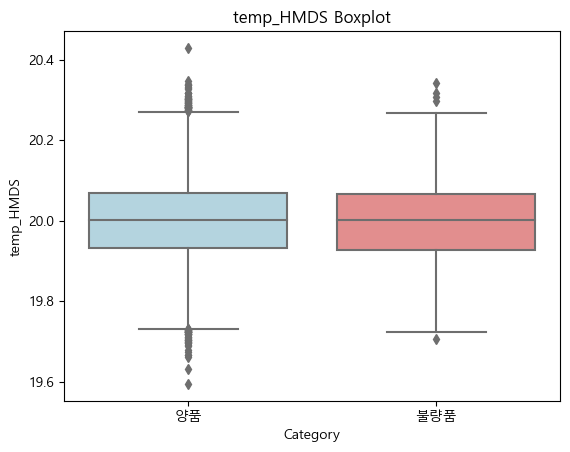

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,20.001084,19.999478,20.000967
std,0.100044,0.099259,0.099985
min,19.594000,19.705000,19.594000
25%,19.933000,19.926500,19.933000
50%,20.001000,20.002000,20.001000
75%,20.068000,20.067000,20.068000
max,20.429000,20.341000,20.429000


In [57]:
# 3. temp_HMDS
twosamplt_ttest(df, 'temp_HMDS', 1)
show_describe(df, 'temp_HMDS')

1. 등분산성 검정 
  검정통계량: 0.0033  p-value : 0.9544 
2. 2-Sample t-test 
  t검정통계량: 0.3211  p-value : 0.7482 
H0: 채택, time_HMDS_bake 에 따른 불량품/양품의 차이가 없다


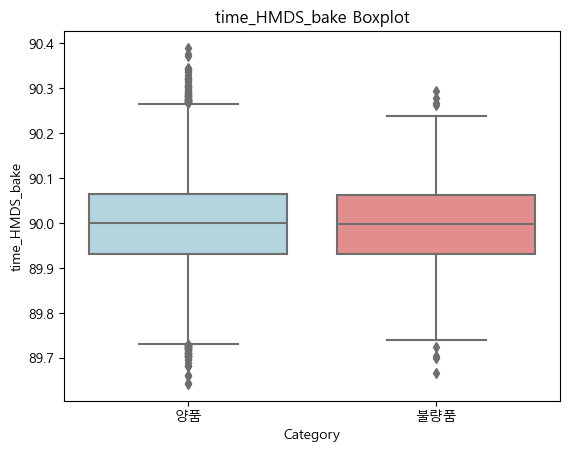

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,89.999363,89.998344,89.999289
std,0.100141,0.100270,0.100147
min,89.643000,89.667000,89.643000
25%,89.932000,89.932000,89.932000
50%,90.000000,89.998000,90.000000
75%,90.066000,90.062500,90.066000
max,90.390000,90.295000,90.390000


In [58]:
# 4. time_HMDS_bake
twosamplt_ttest(df, 'time_HMDS_bake', 1)
show_describe(df, 'time_HMDS_bake')

1. 등분산성 검정 
  검정통계량: 77.9842  p-value : 0.0000 
2. Welch’s t-test 
  t검정통계량: 9.8387  p-value : 0.0000 
H1: 채택, spin1 에 따른 불량품/양품의 차이가 있다


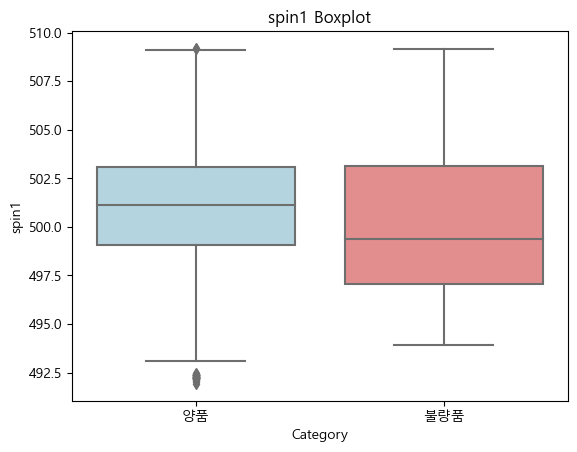

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,500.915464,499.824566,500.836312
std,2.936001,3.541430,2.997316
min,491.918000,493.899000,491.918000
25%,499.075000,497.045000,498.922500
50%,501.115000,499.354000,501.058000
75%,503.105000,503.157000,503.107000
max,509.212000,509.168000,509.212000


In [59]:
# 5. spin1
twosamplt_ttest(df, 'spin1', 1)
show_describe(df, 'spin1')

1. 등분산성 검정 
  검정통계량: 25.7466  p-value : 0.0000 
2. Welch’s t-test 
  t검정통계량: 6.6962  p-value : 0.0000 
H1: 채택, spin2 에 따른 불량품/양품의 차이가 있다


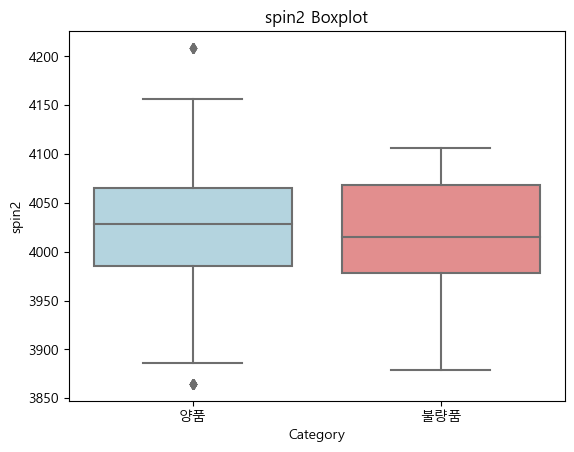

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,4026.048757,4013.825754,4025.161896
std,51.998737,58.054447,52.555248
min,3864.655000,3879.341000,3864.655000
25%,3985.869000,3978.122500,3985.702000
50%,4027.968000,4014.707000,4027.048000
75%,4065.449000,4068.656500,4065.534750
max,4208.748000,4106.055000,4208.748000


In [60]:
# 6. spin2
twosamplt_ttest(df, 'spin2', 1)
show_describe(df, 'spin2')

1. 등분산성 검정 
  검정통계량: 110.3223  p-value : 0.0000 
2. Welch’s t-test 
  t검정통계량: 8.8638  p-value : 0.0000 
H1: 채택, spin3 에 따른 불량품/양품의 차이가 있다


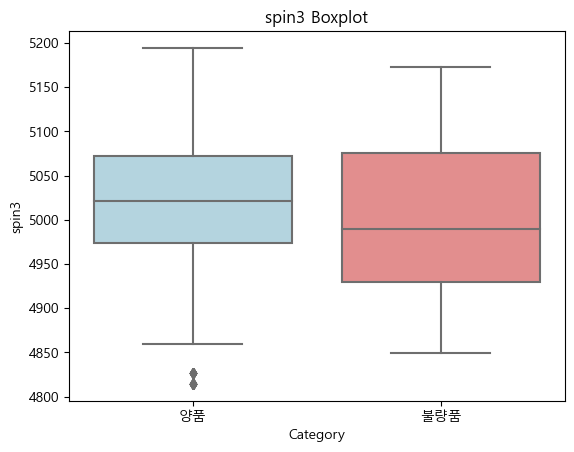

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,5020.739794,4997.556370,5019.057682
std,67.095588,83.676707,68.694377
min,4814.372000,4849.390000,4814.372000
25%,4974.122000,4929.567500,4971.366000
50%,5021.635000,4990.055000,5019.726000
75%,5071.759000,5075.590000,5071.916000
max,5194.329000,5172.266000,5194.329000


In [61]:
# 7. spin3
twosamplt_ttest(df, 'spin3', 1)
show_describe(df, 'spin3')

1. 등분산성 검정 
  검정통계량: 3.3025  p-value : 0.0692 
2. 2-Sample t-test 
  t검정통계량: 7.7070  p-value : 0.0000 
H1: 채택, photoresist_bake 에 따른 불량품/양품의 차이가 있다


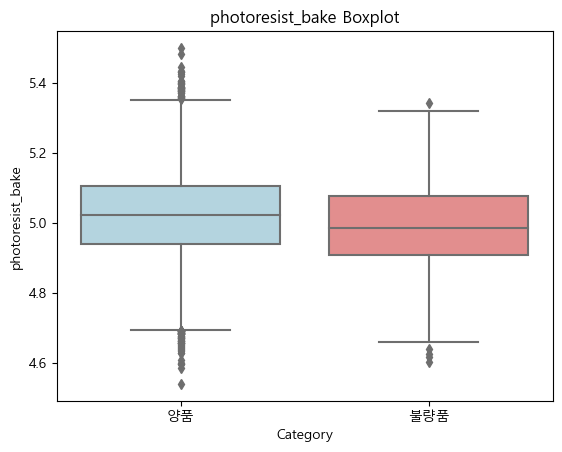

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,5.021681,4.991825,5.019515
std,0.121948,0.126957,0.122559
min,4.540000,4.602000,4.540000
25%,4.940000,4.907500,4.937000
50%,5.022000,4.986000,5.019000
75%,5.105000,5.076500,5.104000
max,5.500000,5.344000,5.500000


In [62]:
# 8. photoresist_bake
twosamplt_ttest(df, 'photoresist_bake', 1)
show_describe(df, 'photoresist_bake')

1. 등분산성 검정 
  검정통계량: 59.4346  p-value : 0.0000 
2. Welch’s t-test 
  t검정통계량: 12.7386  p-value : 0.0000 
H1: 채택, temp_softbake 에 따른 불량품/양품의 차이가 있다


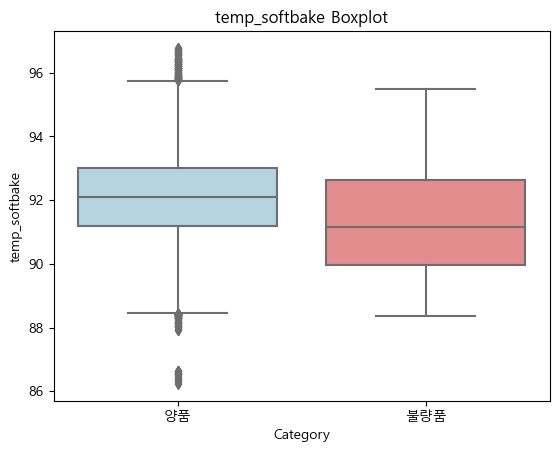

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,92.015882,91.343866,91.967123
std,1.427328,1.682968,1.457793
min,86.230000,88.355000,86.230000
25%,91.182000,89.959000,91.075750
50%,92.090000,91.165000,92.049500
75%,93.010000,92.634500,93.005000
max,96.774000,95.481000,96.774000


In [63]:
# 9. temp_softbake
twosamplt_ttest(df, 'temp_softbake', 1)
show_describe(df, 'temp_softbake')

1. 등분산성 검정 
  검정통계량: 0.2414  p-value : 0.6232 
2. 2-Sample t-test 
  t검정통계량: 0.6407  p-value : 0.5217 
H0: 채택, time_softbake 에 따른 불량품/양품의 차이가 없다


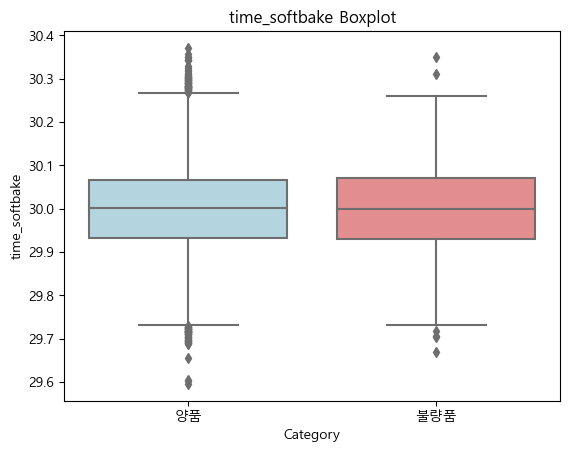

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,30.000160,29.998125,30.000012
std,0.100231,0.101337,0.100310
min,29.596000,29.670000,29.596000
25%,29.933000,29.929500,29.932000
50%,30.001000,29.999000,30.000500
75%,30.067000,30.070000,30.067000
max,30.371000,30.349000,30.371000


In [64]:
# 10. time_softbake
twosamplt_ttest(df, 'time_softbake', 1)
show_describe(df, 'time_softbake')

##### 3. Photo Litho
1. Energy_Exposure

1. 등분산성 검정 
  검정통계량: 12.2787  p-value : 0.0005 
2. Welch’s t-test 
  t검정통계량: -3.3791  p-value : 0.0008 
H1: 채택, Energy_Exposure 에 따른 불량품/양품의 차이가 있다


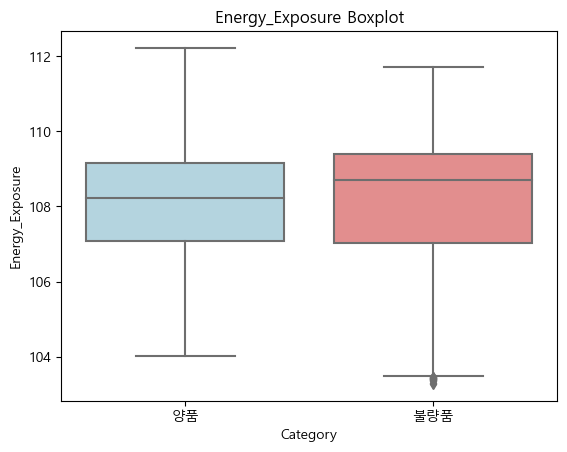

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,108.087324,108.261847,108.099987
std,1.518091,1.639291,1.527821
min,104.029000,103.274000,103.274000
25%,107.076000,107.026500,107.073000
50%,108.233000,108.698000,108.260000
75%,109.152000,109.396000,109.174000
max,112.223000,111.702000,112.223000


In [66]:
# 1. Energy_Exposure
twosamplt_ttest(df, 'Energy_Exposure', 1)
show_describe(df, 'Energy_Exposure')

##### 4. Etching
1. Source Power
2. Temp_Etching

1. 등분산성 검정 
  검정통계량: 0.5995  p-value : 0.4388 
2. 2-Sample t-test 
  t검정통계량: -7.3446  p-value : 0.0000 
H1: 채택, Source_Power 에 따른 불량품/양품의 차이가 있다


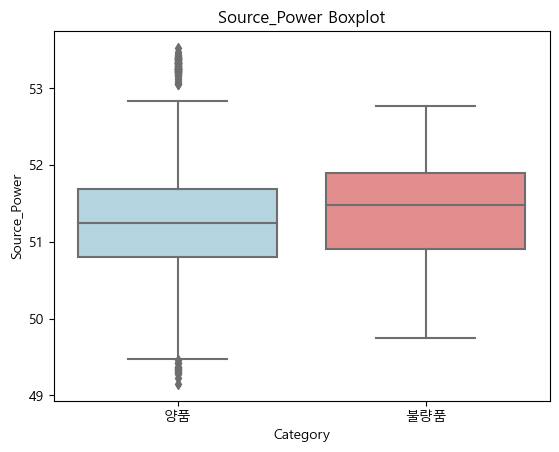

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,51.231042,51.382065,51.241999
std,0.648442,0.659734,0.650426
min,49.149000,49.744000,49.149000
25%,50.799000,50.909500,50.805000
50%,51.243000,51.480000,51.261000
75%,51.690000,51.901500,51.707000
max,53.526000,52.771000,53.526000


In [67]:
# 2. Source_Power       
twosamplt_ttest(df, 'Source_Power', 1)
show_describe(df, 'Source_Power')

1. 등분산성 검정 
  검정통계량: 11.6890  p-value : 0.0006 
2. Welch’s t-test 
  t검정통계량: -11.6477  p-value : 0.0000 
H1: 채택, Temp_Etching 에 따른 불량품/양품의 차이가 있다


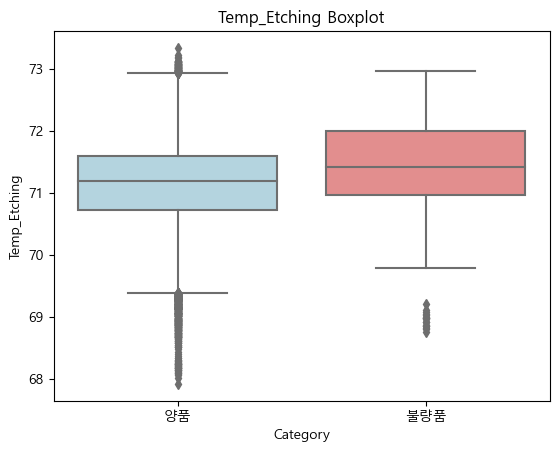

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,71.134855,71.410052,71.154822
std,0.801888,0.741473,0.800823
min,67.914000,68.755000,67.914000
25%,70.716000,70.964500,70.738750
50%,71.196000,71.412000,71.208000
75%,71.602000,71.991000,71.630000
max,73.340000,72.968000,73.340000


In [68]:
# 2. Temp_Etching
twosamplt_ttest(df, 'Temp_Etching', 1)
show_describe(df, 'Temp_Etching')

##### 5. ion
1. RTA_Temp
2. Temp_implantation
3. input_Energy
4. max_flux
5. Furance_temp

1. 등분산성 검정 
  검정통계량: 3.4690  p-value : 0.0625 
2. 2-Sample t-test 
  t검정통계량: -6.5021  p-value : 0.0000 
H1: 채택, RTA_Temp 에 따른 불량품/양품의 차이가 있다


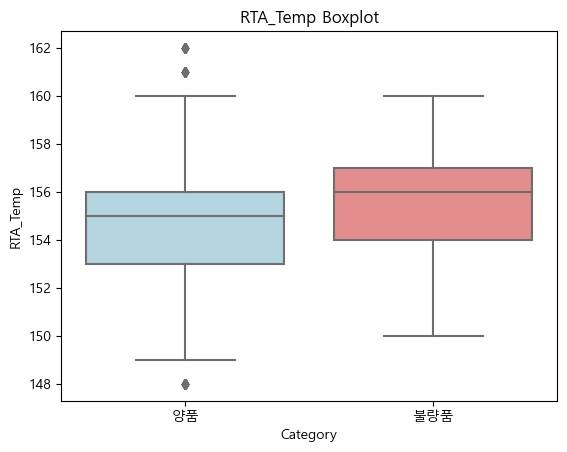

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,154.658831,155.153488,154.694722
std,2.408811,2.314973,2.405476
min,148.000000,150.000000,148.000000
25%,153.000000,154.000000,153.000000
50%,155.000000,156.000000,155.000000
75%,156.000000,157.000000,156.000000
max,162.000000,160.000000,162.000000


In [69]:
# 1. RTA_Temp
twosamplt_ttest(df, 'RTA_Temp', 1)
show_describe(df, 'RTA_Temp')

1. 등분산성 검정 
  검정통계량: 2.3789  p-value : 0.1230 
2. 2-Sample t-test 
  t검정통계량: -9.1245  p-value : 0.0000 
H1: 채택, Temp_implantation 에 따른 불량품/양품의 차이가 있다


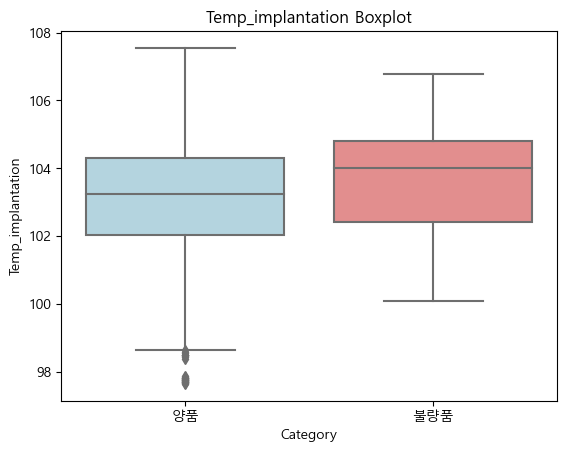

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,103.136323,103.613200,103.170924
std,1.654283,1.597536,1.654810
min,97.649000,100.082000,97.649000
25%,102.040000,102.433500,102.060750
50%,103.247000,104.009000,103.304000
75%,104.309000,104.794500,104.346000
max,107.547000,106.772000,107.547000


In [70]:
# 2. Temp_implantation
twosamplt_ttest(df, 'Temp_implantation', 1)
show_describe(df, 'Temp_implantation')

1. 등분산성 검정 
  검정통계량: 10.6647  p-value : 0.0011 
2. Welch’s t-test 
  t검정통계량: 0.1352  p-value : 0.8925 
H0: 채택, input_Energy 에 따른 불량품/양품의 차이가 없다


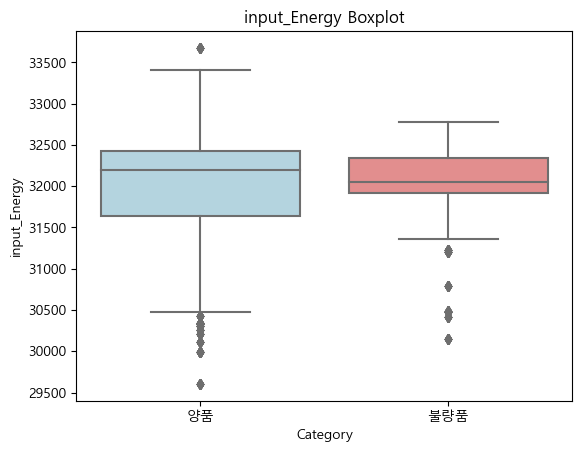

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,32007.365265,32005.000367,32007.193676
std,591.591563,548.986067,588.586858
min,29604.103000,30152.652000,29604.103000
25%,31633.194000,31914.183000,31639.465500
50%,32201.993000,32055.844000,32200.548500
75%,32421.777000,32337.663000,32420.563500
max,33675.751000,32773.542000,33675.751000


In [71]:
# 3. input_Energy
twosamplt_ttest(df, 'input_Energy', 1)
show_describe(df, 'input_Energy')

1. 등분산성 검정 
  검정통계량: 30.8521  p-value : 0.0000 
2. Welch’s t-test 
  t검정통계량: 8.7240  p-value : 0.0000 
H1: 채택, max_flux 에 따른 불량품/양품의 차이가 있다


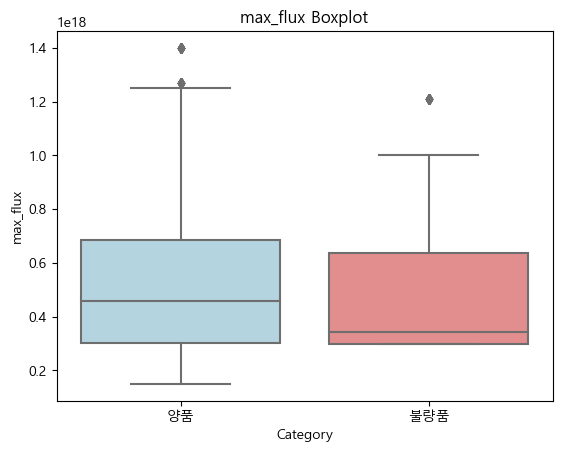

,양품,불량품,전체
count,1.374100e+04,1.075000e+03,1.481600e+04
mean,5.259598e+17,4.648912e+17,5.215289e+17
std,2.488395e+17,2.187054e+17,2.472783e+17
min,1.500000e+17,2.980000e+17,1.500000e+17
25%,3.010000e+17,3.000000e+17,3.010000e+17
50%,4.600000e+17,3.420000e+17,4.530000e+17
75%,6.850000e+17,6.370000e+17,6.720000e+17
max,1.400000e+18,1.210000e+18,1.400000e+18


In [72]:
# 4. max_flux
twosamplt_ttest(df, 'max_flux', 1)
show_describe(df, 'max_flux')

1. 등분산성 검정 
  검정통계량: 17.0120  p-value : 0.0000 
2. Welch’s t-test 
  t검정통계량: 4.9313  p-value : 0.0000 
H1: 채택, Furance_Temp 에 따른 불량품/양품의 차이가 있다


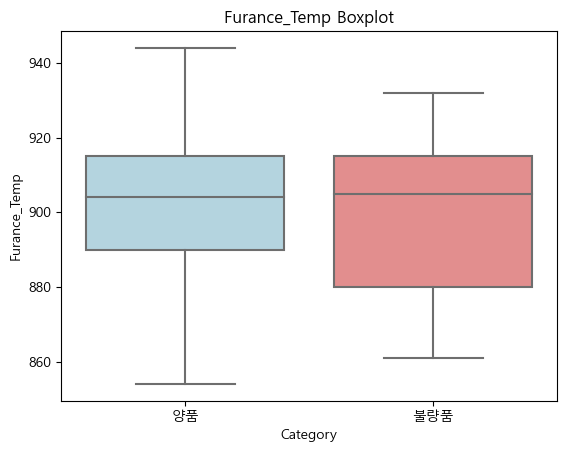

,양품,불량품,전체
count,13741.000000,1075.000000,14816.000000
mean,901.259006,898.122791,901.031452
std,18.462640,20.202692,18.611431
min,854.000000,861.000000,854.000000
25%,890.000000,880.000000,889.000000
50%,904.000000,905.000000,904.000000
75%,915.000000,915.000000,915.000000
max,944.000000,932.000000,944.000000


In [73]:
# 5. Furance_Temp
twosamplt_ttest(df, 'Furance_Temp', 1)
show_describe(df, 'Furance_Temp')

## 카이제곱 검정

In [62]:
# 산화의 type

wet_pos_df = df[(df['type']== 'wet') & (df['y_label'] == 1)]
wet_neg_df = df[(df['type']== 'wet') & (df['y_label'] == 0)]

dry_pos_df = df[(df['type']== 'dry') & (df['y_label'] == 1)]
dry_neg_df = df[(df['type']== 'dry') & (df['y_label'] == 0)]

print("type: wet\n  양품:" , len(wet_neg_df), "불량품:", len(wet_pos_df))
print("type: dry\n  양품:" , len(dry_neg_df), "불량품:", len(dry_pos_df))

type: wet
  양품: 5919 불량품: 258
type: dry
  양품: 7822 불량품: 817


In [63]:
data = np.array([[5919, 7822],  # 양품
                 [258, 817]])   # 불량품

# 카이제곱 검정 수행
chi2, p, dof, expected = stats.chi2_contingency(data)

# 결과 출력
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Frequencies:\n{expected}")


Chi-Square Statistic: 148.4501
P-value: 0.0000
Degrees of Freedom: 1
Expected Frequencies:
[[5728.81729212 8012.18270788]
 [ 448.18270788  626.81729212]]


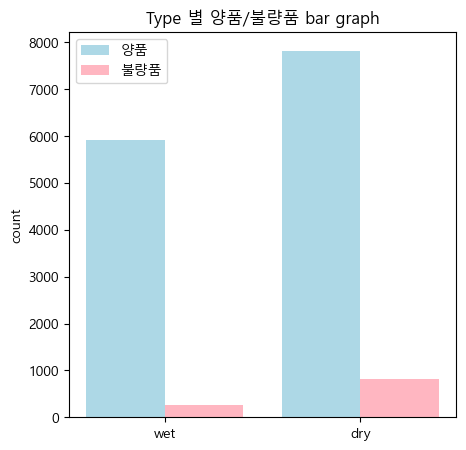

In [64]:
##### 바플롯 그리기
width = 0.2  # 바의 너비
fig, ax = plt.subplots(figsize = (5,5))
labels = ['wet', 'dry']
x = np.arange(len(labels)) * 0.5  # 바의 위치

ax.bar(x - width/2, data[0], color = 'lightblue', width=width, label='양품')
ax.bar(x + width/2, data[1], color = 'lightpink' , width=width, label='불량품')

# 레이블 설정
ax.set_ylabel('count')
ax.set_title('Type 별 양품/불량품 bar graph')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

In [65]:
# 산화의 type

H_pos_df = df[(df['UV_type']== 'H') & (df['y_label'] == 1)]
H_neg_df = df[(df['UV_type']== 'H') & (df['y_label'] == 0)]

G_pos_df = df[(df['UV_type']== 'G') & (df['y_label'] == 1)]
G_neg_df = df[(df['UV_type']== 'G') & (df['y_label'] == 0)]

I_pos_df = df[(df['UV_type']== 'I') & (df['y_label'] == 1)]
I_neg_df = df[(df['UV_type']== 'I') & (df['y_label'] == 0)]

print("UV_type: H\n  양품:" , len(H_neg_df), "불량품:", len(H_pos_df))
print("UV_type: G\n  양품:" , len(G_neg_df), "불량품:", len(G_pos_df))
print("UV_type: I\n  양품:" , len(I_neg_df), "불량품:", len(I_pos_df))

UV_type: H
  양품: 4483 불량품: 472
UV_type: G
  양품: 5119 불량품: 308
UV_type: I
  양품: 4139 불량품: 295


In [66]:
data = np.array([[4483 , 5119, 4139],  # 양품
                 [472, 308, 295]])   # 불량품

# 카이제곱 검정 수행
chi2, p, dof, expected = stats.chi2_contingency(data)

# 결과 출력
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Frequencies:\n{expected}")


Chi-Square Statistic: 60.4789
P-value: 0.0000
Degrees of Freedom: 2
Expected Frequencies:
[[4595.48157397 5033.23481371 4112.28361231]
 [ 359.51842603  393.76518629  321.71638769]]


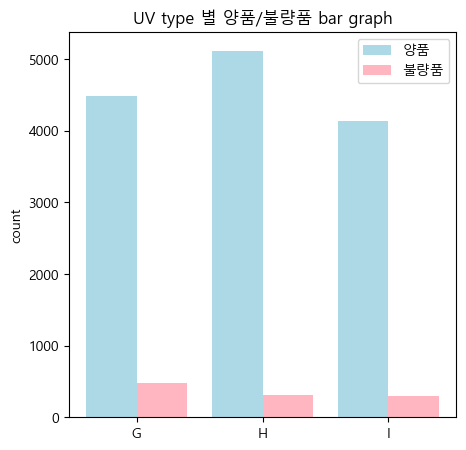

In [69]:
##### 바플롯 그리기
width = 0.2  # 바의 너비
fig, ax = plt.subplots(figsize = (5,5))
labels = ['G','H','I']
x = np.arange(len(labels)) * 0.5  # 바의 위치

ax.bar(x - width/2, data[0], color = 'lightblue', width=width, label='양품')
ax.bar(x + width/2, data[1], color = 'lightpink' , width=width, label='불량품')

# 레이블 설정
ax.set_ylabel('count')
ax.set_title('UV type 별 양품/불량품 bar graph')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

In [68]:
numeric_x = df.select_dtypes(exclude='object')
numeric_x.drop('y_label',axis = 1, inplace = True)
for index, i in enumerate(numeric_x.columns.tolist()):
    print(index)
    twosamplt_ttest(df, i)
    print()

0
1. 등분산성 검정 
  검정통계량: 0.4498  p-value : 0.5024 
2. 2-Sample t-test 
  t검정통계량: 14.6061  p-value : 0.0000 
H1: 채택, Temp_OXid 에 따른 불량품/양품의 차이가 있다

1
1. 등분산성 검정 
  검정통계량: 0.5577  p-value : 0.4552 
2. 2-Sample t-test 
  t검정통계량: 10.5710  p-value : 0.0000 
H1: 채택, ppm 에 따른 불량품/양품의 차이가 있다

2
1. 등분산성 검정 
  검정통계량: 0.0713  p-value : 0.7895 
2. 2-Sample t-test 
  t검정통계량: -0.9369  p-value : 0.3488 
H0: 채택, Pressure 에 따른 불량품/양품의 차이가 없다

3
1. 등분산성 검정 
  검정통계량: 33.8433  p-value : 0.0000 
2. Welch’s t-test 
  t검정통계량: -4.7212  p-value : 0.0000 
H1: 채택, Oxid_time 에 따른 불량품/양품의 차이가 있다

4
1. 등분산성 검정 
  검정통계량: 58.3315  p-value : 0.0000 
2. Welch’s t-test 
  t검정통계량: -19.3047  p-value : 0.0000 
H1: 채택, thickness 에 따른 불량품/양품의 차이가 있다

5
1. 등분산성 검정 
  검정통계량: 2.4631  p-value : 0.1165 
2. 2-Sample t-test 
  t검정통계량: -15.1443  p-value : 0.0000 
H1: 채택, resist_target 에 따른 불량품/양품의 차이가 있다

6
1. 등분산성 검정 
  검정통계량: 41.0000  p-value : 0.0000 
2. Welch’s t-test 
  t검정통계량: -0.7842  p-value : 0.4330 
H0: 채택, N2_HMDS 에 따른 불량품/

# 월/ 요일별 양품/불량품 차이

In [11]:
for_analysis_date = pd.read_csv("../B1_data/preprocessing_data/for_analysis_date.csv")
for_analysis_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14816 entries, 0 to 14815
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Target    14816 non-null  int64 
 1   Datetime  14816 non-null  object
dtypes: int64(1), object(1)
memory usage: 231.6+ KB


## 요일별 양품/불량품 차이

In [12]:
def pn(value):
    if value >= 195:
        return 1
    else:
        return 0

In [29]:
raw_data = pd.read_csv("./full_data.csv")
temp = raw_data[['Datetime','Target']]
temp['Datetime']= pd.to_datetime(temp['Datetime'])
temp['weekday'] = temp['Datetime'].dt.weekday
# weekdays_map = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
# temp['weekday'] = temp['weekday'].map(weekdays_map)
temp.head()

,Datetime,Target,weekday
0,2024-07-01,141,0
1,2024-07-01,55,0
2,2024-07-01,96,0
3,2024-07-01,105,0
4,2024-07-01,79,0


In [30]:
target_sum = temp.groupby('weekday')['Target'].sum()
target_count = temp.groupby('weekday')['Target'].count()
#weekdays_order = ['월', '화', '수', '목', '금', '토', '일']
# target_sum = target_sum.reindex(weekdays_order)
# target_count = target_count.reindex(weekdays_order)
date_df = pd.DataFrame({
    'weekday' : target_sum.index,
    'target_count' : target_count.values,
    'target_sum' : target_sum.values,
    'target_total' : target_count.values * 520
})
date_df['ratio'] = date_df['target_sum'] / date_df['target_total']
date_df

,weekday,target_count,target_sum,target_total,ratio
0,0,2106,209468,1095120,0.191274
1,1,2352,251133,1223040,0.205335
2,2,2028,207229,1054560,0.196508
3,3,2298,237644,1194960,0.198872
4,4,2166,217819,1126320,0.193390
5,5,2220,230093,1154400,0.199318
6,6,2220,233027,1154400,0.201860


In [27]:
copy_df = date_df.copy()
copy_df.loc['total'] = copy_df.sum()
copy_df['ratio'] = copy_df['target_sum'] / copy_df['target_total']
copy_df

,weekday,target_count,target_sum,target_total,ratio
0,월,2106,209468,1095120,0.191274
1,화,2352,251133,1223040,0.205335
2,수,2028,207229,1054560,0.196508
3,목,2298,237644,1194960,0.198872
4,금,2166,217819,1126320,0.193390
5,토,2220,230093,1154400,0.199318
6,일,2220,233027,1154400,0.201860
total,월화수목금토일,15390,1586413,8002800,0.198232


In [13]:
for_analysis_date['Datetime'] = pd.to_datetime(for_analysis_date['Datetime'])
for_analysis_date['weekday']= for_analysis_date['Datetime'].dt.weekday
#for_analysis_date['y_label'] = for_analysis_date['Target'].apply(pn)
weekdays_map = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
for_analysis_date['weekday'] = for_analysis_date['weekday'].map(weekdays_map)
for_analysis_date.head()

,Target,Datetime,weekday
0,141,2024-07-01,월
1,55,2024-07-01,월
2,96,2024-07-01,월
3,105,2024-07-01,월
4,79,2024-07-01,월


In [50]:
target_sum = for_analysis_date.groupby('weekday')['Target'].sum()
target_count = for_analysis_date.groupby('weekday')['Target'].count()
weekdays_order = ['월', '화', '수', '목', '금', '토', '일']
target_sum = target_sum.reindex(weekdays_order)
target_count = target_count.reindex(weekdays_order)
date_df = pd.DataFrame({
    'weekday' : target_sum.index,
    'target_count' : target_count.values,
    'target_sum' : target_sum.values,
    'target_total' : target_count.values * 520
})
date_df['ratio'] = date_df['target_sum'] / date_df['target_total']
date_df

,weekday,target_count,target_sum,target_total,ratio
0,월,2014,198561,1047280,0.189597
1,화,2277,242273,1184040,0.204616
2,수,1949,199199,1013480,0.196550
3,목,2211,228288,1149720,0.198560
4,금,2089,208272,1086280,0.191730
5,토,2138,220197,1111760,0.198062
6,일,2138,222968,1111760,0.200554


In [51]:
copy_df = date_df.copy()
copy_df.loc['total'] = copy_df.sum()
copy_df['ratio'] = copy_df['target_sum'] / copy_df['target_total']
copy_df

,weekday,target_count,target_sum,target_total,ratio
0,월,2014,198561,1047280,0.189597
1,화,2277,242273,1184040,0.204616
2,수,1949,199199,1013480,0.196550
3,목,2211,228288,1149720,0.198560
4,금,2089,208272,1086280,0.191730
5,토,2138,220197,1111760,0.198062
6,일,2138,222968,1111760,0.200554
total,월화수목금토일,14816,1519758,7704320,0.197260


In [52]:
df = pd.DataFrame({
    'target_sum': date_df['target_sum'],
    'nontarget_sum' : date_df['target_total'] - date_df['target_sum']
})

chi, pval, dof, expected = stats.chi2_contingency(df.T)

print( "chi-square test ")
print( ' chisq: {0:0.2f}' .format(chi))
print( ' p-value : {0:0.3f}'.format(pval))
print( ' degree of freedom: {}' .format(dof))
print( ' expected value: \n{}' .format(expected.round(1)))

chi-square test 
 chisq: 1098.95
 p-value : 0.000
 degree of freedom: 6
 expected value: 
[[206587.  233564.3 199919.6 226794.3 214280.1 219306.3 219306.3]
 [840693.  950475.7 813560.4 922925.7 871999.9 892453.7 892453.7]]


In [64]:
result_df = pd.DataFrame({
    '요일' : date_df['weekday'],
    '실제불량칩수': date_df['target_sum'],
    '전체칩수' :date_df['target_total'],
    '불량률' : date_df['ratio'],
    '기댓값': expected[0].round() ,
    '차이': date_df['target_sum'] - expected[0].round()
})
result_df

,요일,실제불량칩수,전체칩수,불량률,기댓값,차이
0,월,198561,1047280,0.189597,206587.0,-8026.0
1,화,242273,1184040,0.204616,233564.0,8709.0
2,수,199199,1013480,0.196550,199920.0,-721.0
3,목,228288,1149720,0.198560,226794.0,1494.0
4,금,208272,1086280,0.191730,214280.0,-6008.0
5,토,220197,1111760,0.198062,219306.0,891.0
6,일,222968,1111760,0.200554,219306.0,3662.0


## 월별 양품/불량품 차이

In [65]:
for_analysis_date['month'] = for_analysis_date['Datetime'].dt.month
for_analysis_date.head()

,Target,Datetime,weekday,month
0,141,2024-07-01,월,7
1,55,2024-07-01,월,7
2,96,2024-07-01,월,7
3,105,2024-07-01,월,7
4,79,2024-07-01,월,7


In [69]:
target_sum = for_analysis_date.groupby('month')['Target'].sum()
target_total = for_analysis_date.groupby('month')['Target'].count()

date_df = pd.DataFrame({
    'month' : target_sum.index,
    'target_count' : target_total.values,
    'target_sum' : target_sum.values,
    'target_total' : target_total.values * 520
})
date_df['ratio'] = date_df['target_sum'] / date_df['target_total']

copy_df = date_df.copy()
copy_df.loc['total'] = copy_df.sum()
copy_df['ratio'] = copy_df['target_sum'] / copy_df['target_total']
copy_df

,month,target_count,target_sum,target_total,ratio
0,1.0,1892.0,202469.0,983840.0,0.205795
1,2.0,1815.0,187108.0,943800.0,0.198250
2,3.0,2057.0,203306.0,1069640.0,0.190070
3,4.0,2081.0,210087.0,1082120.0,0.194144
4,5.0,2138.0,217479.0,1111760.0,0.195617
5,6.0,1993.0,201321.0,1036360.0,0.194258
6,7.0,492.0,45999.0,255840.0,0.179796
7,8.0,589.0,57939.0,306280.0,0.189170
8,9.0,455.0,47134.0,236600.0,0.199214
9,10.0,413.0,44370.0,214760.0,0.206603


In [70]:
df = pd.DataFrame({
    'target_sum': date_df['target_sum'],
    'nontarget_sum' : date_df['target_total'] - date_df['target_sum']
})

chi, pval, dof, expected = stats.chi2_contingency(df.T)

print( "chi-square test ")
print( ' chisq: {0:0.2f}' .format(chi))
print( ' p-value : {0:0.3f}'.format(pval))
print( ' degree of freedom: {}' .format(dof))
print( ' expected value: \n{}' .format(expected.round(1)))

chi-square test 
 chisq: 8932.51
 p-value : 0.000
 degree of freedom: 11
 expected value: 
[[194072.8 186174.5 210997.7 213459.5 219306.3 204432.9  50467.1  60416.9
   46671.8  42363.7  47902.7  43492. ]
 [789767.2 757625.5 858642.3 868660.5 892453.7 831927.1 205372.9 245863.1
  189928.2 172396.3 194937.3 176988. ]]


In [71]:
result_df = pd.DataFrame({
    '요일' : date_df['month'],
    '실제불량칩수': date_df['target_sum'],
    '전체칩수' :date_df['target_total'],
    '불량률' : date_df['ratio'],
    '기댓값': expected[0].round() ,
    '차이': date_df['target_sum'] - expected[0].round()
})
result_df

,요일,실제불량칩수,전체칩수,불량률,기댓값,차이
0,1,202469,983840,0.205795,194073.0,8396.0
1,2,187108,943800,0.198250,186174.0,934.0
2,3,203306,1069640,0.190070,210998.0,-7692.0
3,4,210087,1082120,0.194144,213460.0,-3373.0
4,5,217479,1111760,0.195617,219306.0,-1827.0
5,6,201321,1036360,0.194258,204433.0,-3112.0
6,7,45999,255840,0.179796,50467.0,-4468.0
7,8,57939,306280,0.189170,60417.0,-2478.0
8,9,47134,236600,0.199214,46672.0,462.0
9,10,44370,214760,0.206603,42364.0,2006.0


In [17]:
df = pd.read_csv("../B1_data/preprocessing_data/preprocessing_include_target.csv")

In [21]:
temp = df.groupby('c_path')['Target'].count()
temp.describe()

count     81.000000
mean     182.913580
std       91.725977
min       69.000000
25%       98.000000
50%      216.000000
75%      248.000000
max      391.000000
Name: Target, dtype: float64